# Micromouse - task 4.2, maze photo -> mission commands

Turns a single overhead photo into a wall map of the maze, an occupancy map of the
5x5 obstacle course, a route through both, and the command list the firmware runs.

**Pipeline**

| stage | what happens |
|---|---|
| 1 | find the rig in the photo and flatten the perspective |
| 2 | locate the cyan wall clips -> infer the grid size and spacing |
| 3 | one homography: photo -> exact `N*CELL_PX` maze square |
| 4 | illumination-flattened wall mask |
| 5 | score each of the `2*N*(N+1)` cell edges -> boolean wall map |
| 6 | walls -> graph, BFS shortest path (the obstacle course fenced off) |
| 6b | the course -> occupancy map grown by the robot radius, A*, waypoints |
| 7 | both phases -> one `f`/`l`/`r`/`T`/`D`/`S` command list, exported as a header |

Nothing is hard-coded to this photo except the position of the obstacle course,
which the brief allows: the grid size, the maze corners and the cell pitch are
all measured from the image.

**Conventions.** Every heading in this notebook is in degrees, counter-clockwise
positive, with 0 = East - the convention the firmware turns in. Cells are
`(row, col)` with row 0 at the top of the photo, so North is a smaller row.

In [1]:
import math
import textwrap
import heapq
from collections import deque

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ----------------------------------------------------------------- tunables
PHOTO       = "tues_maze_2.jpg"

CELL_PX     = 100          # px per maze cell in the rectified image
COARSE_PX   = 900          # size of the first (rig) rectification
CELL_SIZE_MM = 180         # physical size of one cell in mm
MM_PER_PX   = CELL_SIZE_MM / CELL_PX

CLIP_HUE    = (78, 110)    # OpenCV hue window for the cyan wall clips
CLIP_SAT    = 70
CLIP_VAL    = 80
CLIP_AREA   = 25           # min blob area (px) to count as a clip
CLIP_TOL    = 25           # px: clips closer than this share a grid line

WALL_LEVEL  = 200          # flattened-gray below this = wall pixel
EDGE_HALF   = 22           # px band either side of a cell edge when scoring
EDGE_TRIM   = 0.22         # ignore this fraction at each end (posts/corners)
WALL_THR    = 0.50         # fraction of the edge that must be dark

# ------------------------------------------------------------- the robot
# Half-width of the chassis at its widest, and the clearance we insist on
# keeping on top of it. Obstacles in the course are grown by the sum, which
# turns "does the whole footprint fit here" into "is this one pixel free" - so
# any path A* returns is a path the robot fits down.
#
# MEASURE THIS. Too small and the planner will cheerfully route through a gap
# the chassis cannot enter, and the brief ends the run on the second collision.
ROBOT_RADIUS_MM  = 75
SAFETY_MARGIN_MM = 10

# Floor for the clearance sweep in plan_zone(). A 100mm cylinder in a 180mm cell
# leaves 40mm either side, so at full radius parts of the course are genuinely
# impassable and insisting on it would just fail. The sweep drops to the largest
# clearance that does have a route and says loudly what it settled for.
MIN_CLEARANCE_MM = 30

# --------------------------------------------------------------- the plan
# Shortest leg the planner will hand the robot. Anything shorter is merged into
# its neighbour, because a turn-and-drive of a few mm costs a full accelerate,
# settle and turn to achieve nothing - and a drive below the firmware's deadband
# is skipped on the robot while its turn is not, which would leave it rotating
# on the spot for no travel.
MIN_SEGMENT_MM = 25.0

# ------------------------------------------------------- firmware deadbands
# What the robot can actually execute. turnByAngleProfiled settles in a 1.2 deg
# deadband and cannot push below MIN_TURNING_PWM, so a 2 deg turn is a bang-bang
# across the band rather than a turn; the drive deadband is 3mm. Kept in step
# with MISSION_MIN_TURN / MISSION_MIN_DRIVE in task4_2ChainingMovements.hpp.
#
# Note that undersized TURNS are still exported. chainMission() skips executing
# them but still adds them to its heading, so dropping them here instead would
# put the two accumulators out of step and mis-plan everything after the snap.
MIN_TURN_DEG = 3.0
MIN_DRIVE_MM = 5.0

# ------------------------------------------------------------- conventions
# Headings in degrees, COUNTER-CLOCKWISE POSITIVE, 0 = East. Everything in this
# notebook is in this convention - the grid phase, the continuous phase and both
# exports - because it is the one the firmware turns in (TURN_LEFT = +90) and the
# one atan2(-(y2-y1), x2-x1) produces on an image whose y axis points down.
# Row 0 is the top of the photo, so a smaller row is North.
HEADING_DEG = {"N": 90.0, "E": 0.0, "S": -90.0, "W": 180.0}

# Start pose and goal as (row, col), zero-indexed, row 0 at the top of the photo.
# START_HEADING is which way the robot is physically placed on the day - it must
# match MISSION_START_HEADING in task4_code/task4_2ChainingMovements.hpp.
START         = (2, 2)
START_HEADING = HEADING_DEG["E"]
GOAL          = (6, 7)

# The brief specifies the goal as (row, col) only, so the final heading is free.
# Set this to "N"/"E"/"S"/"W" to also park the robot facing a given way.
GOAL_HEADING = None

# ------------------------------------------------------- the obstacle course
# Top-left cell of the 5x5 obstacle section, and the cells the robot enters and
# leaves it by. Hardcoding the position of the course is what the brief allows.
ZONE_START_R, ZONE_START_C = 1, 3
ZONE_SIZE = 5
ZONE_ENTER = (2, 3)
ZONE_EXIT  = (5, 7)


def zone_px(cell):
    """Maze cell -> the centre of that cell in the zone ROI's pixel frame, (x, y)."""
    r, c = cell
    return (int((c - ZONE_START_C + 0.5) * CELL_PX),
            int((r - ZONE_START_R + 0.5) * CELL_PX))


# Derived, not typed in twice: these used to be two hardcoded pixel pairs that
# had to be kept in step with ZONE_ENTER/ZONE_EXIT by hand.
ZONE_START_PX = zone_px(ZONE_ENTER)
ZONE_GOAL_PX  = zone_px(ZONE_EXIT)


def round_half_away(x):
    """Round halves away from zero, the way C's roundf() does.

    Python's round() rounds halves to even, so round(-0.5) is 0 where roundf is
    -1. The firmware snaps its heading with roundf, and this notebook has to
    predict that snap exactly or phase 4 is planned from the wrong grid.
    """
    return math.floor(x + 0.5) if x >= 0 else math.ceil(x - 0.5)


PATH_DOT = "•"

plt.rcParams["figure.dpi"] = 110
print("OpenCV", cv2.__version__, "| NumPy", np.__version__)
print(f"start {START} facing {START_HEADING:+.0f} deg  ->  zone {ZONE_ENTER} .. {ZONE_EXIT}  ->  goal {GOAL}")
print(f"zone entrance/exit in ROI pixels: {ZONE_START_PX} -> {ZONE_GOAL_PX}")

OpenCV 5.0.0 | NumPy 2.4.4
start (2, 2) facing +0 deg  ->  zone (2, 3) .. (5, 7)  ->  goal (6, 7)
zone entrance/exit in ROI pixels: (50, 150) -> (450, 450)


## Stage 1 — find the rig and flatten it

The rig is by far the largest bright object in the frame, so: threshold → largest
connected component → fill holes → 4-point polygon. That quad is the perspective
reference. No hand-typed pixel coordinates, and it re-derives itself for a
re-shot photo.

In [2]:
def order_quad(pts):
    """Return the 4 points ordered top-left, top-right, bottom-right, bottom-left."""
    p = np.asarray(pts, np.float32).reshape(-1, 2)
    s, d = p.sum(axis=1), p[:, 0] - p[:, 1]
    return np.float32([p[np.argmin(s)],    # tl: smallest x+y
                       p[np.argmax(d)],    # tr: largest  x-y
                       p[np.argmax(s)],    # br: largest  x+y
                       p[np.argmin(d)]])   # bl: smallest x-y


def largest_bright_blob(bgr, level):
    """Binary mask of the biggest bright region, with interior holes filled."""
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    mask = cv2.morphologyEx((gray > level).astype(np.uint8) * 255,
                            cv2.MORPH_CLOSE, np.ones((21, 21), np.uint8))

    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    biggest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = (labels == biggest).astype(np.uint8) * 255

    # flood the outside from a corner, then invert it to get the holes
    flooded = mask.copy()
    cv2.floodFill(flooded, np.zeros((h + 2, w + 2), np.uint8), (0, 0), 255)
    return mask | cv2.bitwise_not(flooded)


def find_rig_quad(bgr, level=130):
    mask = largest_bright_blob(bgr, level)
    contour = max(cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)[0], key=cv2.contourArea)

    quad = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
    if len(quad) != 4:                       # fall back if the outline is noisy
        quad = cv2.boxPoints(cv2.minAreaRect(contour))
    return order_quad(quad)


def square_transform(quad, size):
    """Homography mapping `quad` onto a `size` x `size` square."""
    return cv2.getPerspectiveTransform(
        quad, np.float32([[0, 0], [size, 0], [size, size], [0, size]]))

rig corners (tl, tr, br, bl):
  tl  (    0.0,    12.0)
  tr  ( 1279.0,     0.0)
  br  ( 1279.0,  1267.0)
  bl  (    0.0,  1267.0)


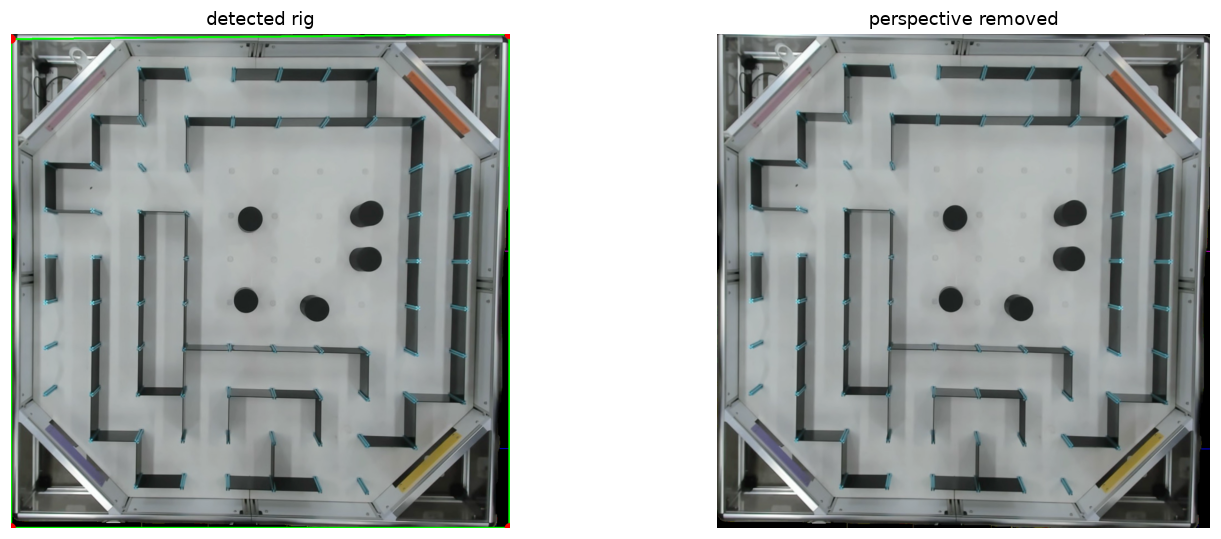

In [3]:
photo = cv2.imread(PHOTO)
if photo is None:
    raise FileNotFoundError(f"could not read {PHOTO!r} - run this notebook from src/task4_code/")

rig_quad = find_rig_quad(photo)
M_coarse = square_transform(rig_quad, COARSE_PX)
coarse   = cv2.warpPerspective(photo, M_coarse, (COARSE_PX, COARSE_PX))

print("rig corners (tl, tr, br, bl):")
for name, (x, y) in zip("tl tr br bl".split(), rig_quad):
    print(f"  {name}  ({x:7.1f}, {y:7.1f})")

marked = photo.copy()
cv2.polylines(marked, [rig_quad.astype(int)], True, (0, 255, 0), 4)
for x, y in rig_quad.astype(int):
    cv2.circle(marked, (x, y), 12, (0, 0, 255), -1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB)); ax[0].set_title("detected rig")
ax[1].imshow(cv2.cvtColor(coarse, cv2.COLOR_BGR2RGB)); ax[1].set_title("perspective removed")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Stage 2 — read the grid off the wall clips

Every wall is held by a pair of cyan clips, and those clips sit on cell corners.
Isolating them by hue and clustering their centres in x and y recovers the grid
lines directly from the hardware — which is far more reliable than assuming the
maze fills the board.

This maze is 9 × 9, but rows and columns are counted **independently** and
`ROWS`/`COLS` are carried separately from here on, so the size is measured rather
than asserted and a re-shot or differently-shaped board needs no code change.

In [4]:
def find_clips(bgr):
    """Centroids of the cyan wall clips."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hue, sat, val = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    mask = ((hue > CLIP_HUE[0]) & (hue < CLIP_HUE[1]) &
            (sat > CLIP_SAT) & (val > CLIP_VAL)).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

    n, _, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    return np.array([centroids[i] for i in range(1, n)
                     if stats[i, cv2.CC_STAT_AREA] >= CLIP_AREA])


def cluster_1d(values, tol):
    """Collapse 1-D values into groups whose neighbours are within `tol`."""
    ordered = np.sort(np.asarray(values, float))
    groups = [[ordered[0]]]
    for v in ordered[1:]:
        if v - groups[-1][-1] <= tol:
            groups[-1].append(v)
        else:
            groups.append([v])
    return np.array([np.mean(g) for g in groups])


def infer_grid(clips, tol=CLIP_TOL):
    """Grid line positions (xs, ys) implied by the clip centroids."""
    return cluster_1d(clips[:, 0], tol), cluster_1d(clips[:, 1], tol)

55 clips  ->  9 rows x 9 cols
x lines: [ 68.  150.5 233.6 315.6 398.9 481.9 564.6 644.6 731.3 814.6]
y lines: [ 66.4 152.6 237.4 322.5 406.8 490.5 576.  656.1 735.5 819.8]
cell pitch: 82.9 px (x), 83.7 px (y)


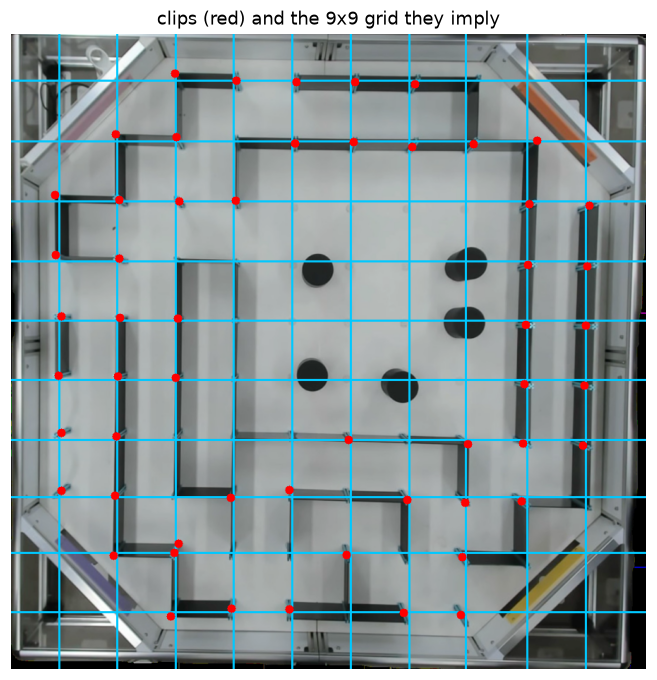

In [5]:
clips  = find_clips(coarse)
gx, gy = infer_grid(clips)

# Counted independently rather than assumed equal, so the size comes from the
# photo. For this board both come out as 9.
COLS, ROWS = len(gx) - 1, len(gy) - 1
if ROWS < 2 or COLS < 2:
    raise RuntimeError(f"implausible {ROWS} x {COLS} grid from {len(clips)} clips "
                       "- widen CLIP_TOL or the hue window")

print(f"{len(clips)} clips  ->  {ROWS} rows x {COLS} cols")
print("x lines:", np.round(gx, 1))
print("y lines:", np.round(gy, 1))
print("cell pitch: %.1f px (x), %.1f px (y)" % (np.diff(gx).mean(), np.diff(gy).mean()))

vis = coarse.copy()
for x in gx: cv2.line(vis, (int(x), 0), (int(x), COARSE_PX), (255, 200, 0), 2)
for y in gy: cv2.line(vis, (0, int(y)), (COARSE_PX, int(y)), (255, 200, 0), 2)
for x, y in clips.astype(int): cv2.circle(vis, (x, y), 6, (0, 0, 255), -1)

plt.figure(figsize=(7.5, 7.5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"clips (red) and the {ROWS}x{COLS} grid they imply")
plt.axis("off"); plt.show()

## Stage 3 — one homography, photo → maze square

Rather than warping twice and losing sharpness, the rig transform and the
grid-fitting transform are multiplied into a single matrix `M`. The result is a
square where **cell `(r, c)` is exactly the box `[c·CELL_PX, (c+1)·CELL_PX] ×
[r·CELL_PX, (r+1)·CELL_PX]`** — so every later step is plain array slicing.

rectified maze: 900 x 900 px, 100 px per cell


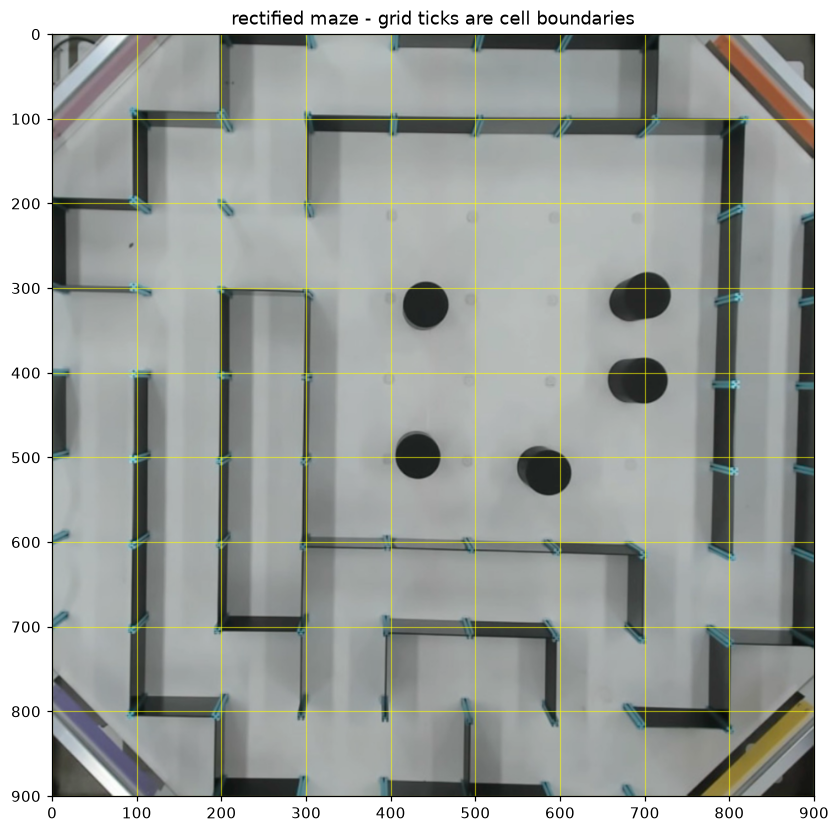

In [6]:
MAZE_W, MAZE_H = COLS * CELL_PX, ROWS * CELL_PX
grid_quad = np.float32([[gx[0],  gy[0]],  [gx[-1], gy[0]],
                        [gx[-1], gy[-1]], [gx[0],  gy[-1]]])

M = cv2.getPerspectiveTransform(
        grid_quad,
        np.float32([[0, 0], [MAZE_W, 0], [MAZE_W, MAZE_H], [0, MAZE_H]])) @ M_coarse
maze_img = cv2.warpPerspective(photo, M, (MAZE_W, MAZE_H))

def cell_centre(r, c):
    return int((c + 0.5) * CELL_PX), int((r + 0.5) * CELL_PX)

print(f"rectified maze: {maze_img.shape[1]} x {maze_img.shape[0]} px, {CELL_PX} px per cell")

plt.figure(figsize=(8 * COLS / max(ROWS, COLS) + 2, 8 * ROWS / max(ROWS, COLS) + 1))
plt.imshow(cv2.cvtColor(maze_img, cv2.COLOR_BGR2RGB))
plt.xticks(np.arange(0, MAZE_W + 1, CELL_PX)); plt.yticks(np.arange(0, MAZE_H + 1, CELL_PX))
plt.grid(color="yellow", alpha=.55)
plt.title("rectified maze - grid ticks are cell boundaries")
plt.show()

## Stage 4 — wall pixels

The board is lit unevenly (bright at the top, shadowed at the bottom), so a fixed
grey threshold cannot separate wall from floor across the whole image. A
morphological *closing* with a kernel wider than any wall estimates the local
floor brightness; dividing by it flattens the lighting and leaves a threshold
that works everywhere.

wall pixels: 21.7% of the board


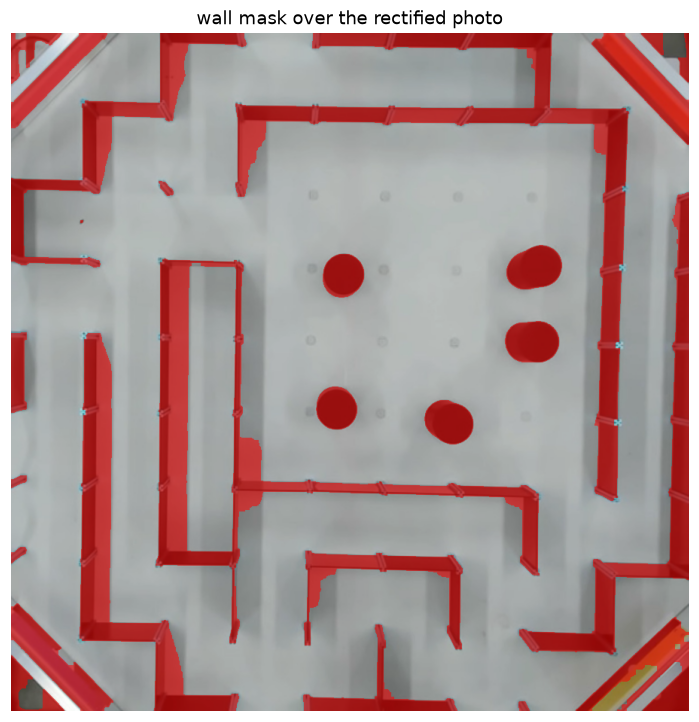

In [7]:
def wall_pixels(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # closing with a kernel wider than a wall keeps only the floor -> local brightness
    floor = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, np.ones((61, 61), np.uint8))
    flat  = cv2.divide(gray, floor, scale=255)

    mask = (flat < WALL_LEVEL).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((3, 3), np.uint8))   # speckle
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))   # seams
    return mask


# NOTE: this is a 0/1 mask, not 0/255. edge_score() below takes the mean of it to
# get a covered fraction, so the values have to stay 0/1 - which means anything
# inverting it must test against zero rather than reach for cv2.bitwise_not,
# since bitwise_not(1) is 254 and 254 is just as true as 255.
wall_mask = wall_pixels(maze_img)
print(f"wall pixels: {wall_mask.mean():.1%} of the board")

tint = maze_img.copy(); tint[wall_mask > 0] = (0, 0, 255)
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(cv2.addWeighted(maze_img, .45, tint, .55, 0), cv2.COLOR_BGR2RGB))
plt.title("wall mask over the rectified photo"); plt.axis("off"); plt.show()


def zone_roi(array):
    """The 5x5 obstacle course, cut out of a full-board image or mask."""
    y0, x0 = ZONE_START_R * CELL_PX, ZONE_START_C * CELL_PX
    y1, x1 = y0 + ZONE_SIZE * CELL_PX, x0 + ZONE_SIZE * CELL_PX
    return array[y0:y1, x0:x1]


def free_space_at(clearance_mm):
    """Occupancy map of the course: 255 where the robot's CENTRE may sit.

    Configuration-space mapping. Every obstacle pixel - cylinder or maze wall,
    the mask does not distinguish and does not need to - is grown by
    `clearance_mm`, so a single free pixel means the entire footprint is clear
    there. That is what makes a point-robot A* on this map a valid plan for a
    chassis that is most of a cell wide.
    """
    radius_px = max(1, int(round(clearance_mm / MM_PER_PX)))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                       (2 * radius_px + 1, 2 * radius_px + 1))
    grown = cv2.dilate(zone_roi(wall_mask), kernel)

    # Explicit test against zero rather than cv2.bitwise_not, which on this 0/1
    # mask returns 254 for obstacle and 255 for free. Both are non-zero, so the
    # collision test in astar_pixel_grid never fired and it planned straight
    # through the cylinders.
    return (grown == 0).astype(np.uint8) * 255

## Stage 5 — from pixels to a wall map

This is the step the old ray-casting approach got wrong. Sampling a straight line
between two cell centres asks *"is anything dark in the way"*, which fires on the
side face of a neighbouring wall and misses walls the line clips at an angle.

Instead each **cell edge** is scored on its own. For the edge between two cells we
take a band `±EDGE_HALF` px around it, collapse it along the short axis (so a wall
counts wherever it falls inside the band — this absorbs the parallax lean of a
5 cm wall seen from a camera that is not directly above it), and ask what
fraction of the edge's length is covered.

The ends are trimmed by `EDGE_TRIM`, because the clips and any perpendicular wall
meeting at that corner would otherwise vote for a wall that is not there.

In [8]:
def edge_score(mask, kind, r, c):
    """Covered fraction of one cell edge.

    kind 'H' -> the horizontal edge on the NORTH side of cell (r, c)
    kind 'V' -> the vertical   edge on the WEST  side of cell (r, c)
    """
    trim = int(CELL_PX * EDGE_TRIM)

    if kind == "H":
        y, x0, x1 = r * CELL_PX, c * CELL_PX, (c + 1) * CELL_PX
        band  = mask[max(0, y - EDGE_HALF):y + EDGE_HALF + 1, x0 + trim:x1 - trim]
        along = band.max(axis=0)          # per column: any wall pixel in the band?
    else:
        x, y0, y1 = c * CELL_PX, r * CELL_PX, (r + 1) * CELL_PX
        band  = mask[y0 + trim:y1 - trim, max(0, x - EDGE_HALF):x + EDGE_HALF + 1]
        along = band.max(axis=1)

    return float(along.mean()) if along.size else 0.0


def build_walls(mask, rows, cols):
    """Score every edge, then threshold into two boolean wall maps.

    H[r, c] - wall on the north side of (r, c);  shape (rows+1, cols)
    V[r, c] - wall on the west  side of (r, c);  shape (rows, cols+1)
    """
    h_score = np.array([[edge_score(mask, "H", r, c) for c in range(cols)] for r in range(rows + 1)])
    v_score = np.array([[edge_score(mask, "V", r, c) for c in range(cols + 1)] for r in range(rows)])

    H, V = h_score >= WALL_THR, v_score >= WALL_THR

    # the board edge is a physical barrier even where no wall is clipped to it
    H[0, :] = H[-1, :] = True
    V[:, 0] = V[:, -1] = True
    return H, V, h_score, v_score


H, V, h_score, v_score = build_walls(wall_mask, ROWS, COLS)
print(f"walls found: {H.sum()} horizontal, {V.sum()} vertical "
      f"(of {H.size} and {V.size} possible edges)")

walls found: 44 horizontal, 50 vertical (of 90 and 90 possible edges)


## Stage 6 — the maze as a graph

`Maze` owns the wall maps and answers connectivity questions; `Graph` is the
explicit adjacency structure built from it. Node ids follow the existing
convention, `id = row · COLS + col`, so they read left-to-right then top-to-bottom.

Headings are ordered clockwise, which is what makes the turn from any heading to
any other a single modulo-4 subtraction — so **every** starting orientation is
handled, a 180° reversal included.

In [9]:
HEADINGS = ["N", "E", "S", "W"]                                  # clockwise
DELTA    = {"N": (-1, 0), "E": (0, 1), "S": (1, 0), "W": (0, -1)}


class Node:
    def __init__(self, node_id, x, y):
        self.id, self.x, self.y = node_id, x, y

    def get_point(self):
        return self.x, self.y

    def __repr__(self):
        return f"Node({self.id} @ {self.x},{self.y})"


class Graph:
    def __init__(self):
        self.nodes, self.edges = {}, {}

    def add_node(self, node_id, x, y):
        self.nodes[node_id] = Node(node_id, x, y)
        self.edges.setdefault(node_id, [])

    def add_edge(self, a, b, weight=1):
        self.edges[a].append((b, weight))

    def remove_edge(self, a, b):
        # the original broke out of the loop after one iteration regardless
        self.edges[a] = [e for e in self.edges[a] if e[0] != b]

    def neighbours(self, node_id):
        return [n for n, _ in self.edges[node_id]]

    def get_edge_weight(self, a, b):
        return next((w for n, w in self.edges[a] if n == b), None)

    def __repr__(self):
        return f"Graph({len(self.nodes)} nodes, {sum(map(len, self.edges.values()))} directed edges)"


class Maze:
    """Wall maps plus the search routines that run on them."""

    def __init__(self, H, V):
        self.H, self.V = H, V
        self.rows, self.cols = H.shape[0] - 1, H.shape[1]

        # Cells the grid search is not allowed to enter, whatever the walls say.
        # This is how the obstacle course is kept out of the discrete phase: the
        # wall scores inside it are read off cylinders standing on open floor and
        # mean nothing, so a BFS that cut through the zone would be routing the
        # grid phase straight through the obstacles. See the cell below.
        self.blocked = set()

    @property
    def shape(self):
        return self.rows, self.cols

    def inside(self, r, c):
        return 0 <= r < self.rows and 0 <= c < self.cols

    # ---------------------------------------------------------- topology
    def wall(self, r, c, d):
        return bool({"N": self.H[r, c],     "S": self.H[r + 1, c],
                     "W": self.V[r, c],     "E": self.V[r, c + 1]}[d])

    def neighbours(self, r, c):
        for d, (dr, dc) in DELTA.items():
            nr, nc = r + dr, c + dc
            if (self.inside(nr, nc) and (nr, nc) not in self.blocked
                    and not self.wall(r, c, d)):
                yield (nr, nc), d

    def cells(self):
        for r in range(self.rows):
            for c in range(self.cols):
                yield r, c

    # id = row * cols + col, so ids read left-to-right then top-to-bottom
    def node_id(self, r, c):
        return r * self.cols + c

    def cell(self, node_id):
        return divmod(node_id, self.cols)

    def to_graph(self):
        g = Graph()
        for r, c in self.cells():
            x, y = cell_centre(r, c)
            g.add_node(self.node_id(r, c), x, y)
        for r, c in self.cells():
            for (nr, nc), _ in self.neighbours(r, c):
                g.add_edge(self.node_id(r, c), self.node_id(nr, nc), 1)
        return g

    # ---------------------------------------------------------- search
    def bfs(self, start, goal):
        """Fewest-cells path from start to goal, or None."""
        if start == goal:
            return [start]

        came_from = {start: None}
        queue = deque([start])
        while queue:
            current = queue.popleft()
            for nb, _ in self.neighbours(*current):
                if nb in came_from:
                    continue
                came_from[nb] = current
                if nb == goal:
                    path = [nb]
                    while came_from[path[-1]] is not None:
                        path.append(came_from[path[-1]])
                    return path[::-1]
                queue.append(nb)
        return None

    def flood(self, goal):
        """Classic micromouse flood fill: cell -> moves to reach `goal` (-1 = unreachable)."""
        dist = np.full((self.rows, self.cols), -1, int)
        dist[goal] = 0
        queue = deque([goal])
        while queue:
            current = queue.popleft()
            for nb, _ in self.neighbours(*current):
                if dist[nb] < 0:
                    dist[nb] = dist[current] + 1
                    queue.append(nb)
        return dist

    def components(self):
        seen, groups = set(), []
        for start in self.cells():
            if start in seen:
                continue
            queue, group = deque([start]), []
            seen.add(start)
            while queue:
                current = queue.popleft()
                group.append(current)
                for nb, _ in self.neighbours(*current):
                    if nb not in seen:
                        seen.add(nb)
                        queue.append(nb)
            groups.append(group)
        return sorted(groups, key=len, reverse=True)

    # ---------------------------------------------------------- rendering
    def ascii(self, path=(), start=None, goal=None):
        marks = {cell: PATH_DOT for cell in path}
        if start is not None: marks[start] = "S"
        if goal  is not None: marks[goal]  = "G"

        lines = []
        for r in range(self.rows + 1):
            lines.append("".join("+" + ("---" if self.H[r, c] else "   ")
                                 for c in range(self.cols)) + "+")
            if r < self.rows:
                lines.append("".join(("|" if self.V[r, c] else " ") + f" {marks.get((r, c), ' ')} "
                                     for c in range(self.cols))
                             + ("|" if self.V[r, self.cols] else " "))
        return "\n".join(lines)

In [10]:
maze = Maze(H, V)

# Fence the obstacle course off from the grid search. Everything inside the 5x5
# is open floor with cylinders on it, so the edge scores there describe obstacles
# rather than walls - and left reachable, BFS would happily find a "shorter"
# grid route through the middle of the course. Only the entrance and exit stay
# open, because that is where the two phases hand over to each other.
ZONE_CELLS = {(r, c)
              for r in range(ZONE_START_R, ZONE_START_R + ZONE_SIZE)
              for c in range(ZONE_START_C, ZONE_START_C + ZONE_SIZE)}
maze.blocked = ZONE_CELLS - {ZONE_ENTER, ZONE_EXIT}

graph = maze.to_graph()
print(graph)
print(f"grid search may not enter {len(maze.blocked)} zone cells "
      f"(entrance {ZONE_ENTER} and exit {ZONE_EXIT} stay open)")

Graph(81 nodes, 103 directed edges)
grid search may not enter 23 zone cells (entrance (2, 3) and exit (5, 7) stay open)


## Stage 6b - the obstacle course as a continuous plan

The grid search stops at the edge of the 5x5. Inside it there are no cells to
speak of, just open floor with 100mm cylinders on it, so the plan is made in
pixels instead.

The occupancy map is a **configuration space**: every obstacle is grown by the
robot's radius plus a safety margin, which reduces "does the whole chassis fit
here" to "is this one pixel free" and makes a point-robot A* a valid plan for a
robot that is most of a cell wide. A* then runs 8-connected over it, and string
pulling reduces the pixel path to the handful of straight legs the robot
actually drives - each one checked against the map before it is accepted, since
cutting a corner is exactly where a chassis clips a cylinder.

The clearance is swept downwards until a route exists, and the figure below says
what it settled for. A 100mm cylinder in a 180mm cell leaves 40mm either side, so
at full radius parts of the course really are impassable - the honest answer is
to go round, not to quietly plan at a radius that does not fit.

In [11]:
def astar_pixel_grid(free_space, start, goal):
    """Shortest 8-connected route across the occupancy map. Points are (x, y)."""
    h, w = free_space.shape

    if free_space[start[1], start[0]] == 0 or free_space[goal[1], goal[0]] == 0:
        return None

    # 8-connected grid (diagonals cost sqrt 2)
    neighbors = [(0, 1, 1.0), (1, 0, 1.0), (0, -1, 1.0), (-1, 0, 1.0),
                 (1, 1, 1.414), (1, -1, 1.414), (-1, 1, 1.414), (-1, -1, 1.414)]

    open_set = [(0.0, start)]
    came_from = {}
    g_score = {start: 0.0}
    closed = set()

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        # The queue can hold several entries for the same pixel; the first one
        # popped is the cheapest, so the rest are stale and can be dropped.
        if current in closed:
            continue
        closed.add(current)

        for dx, dy, cost in neighbors:
            nx, ny = current[0] + dx, current[1] + dy

            if not (0 <= nx < w and 0 <= ny < h) or free_space[ny, nx] == 0:
                continue

            neighbor = (nx, ny)
            tentative_g = g_score[current] + cost
            if tentative_g < g_score.get(neighbor, float("inf")):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score = tentative_g + math.hypot(goal[0] - nx, goal[1] - ny)
                heapq.heappush(open_set, (f_score, neighbor))
    return None


def segment_clear(free_space, a, b):
    """True if the straight line from a to b stays inside free space."""
    h, w = free_space.shape
    (x0, y0), (x1, y1) = a, b

    steps = int(max(abs(x1 - x0), abs(y1 - y0)))
    if steps == 0:
        return 0 <= x0 < w and 0 <= y0 < h and free_space[y0, x0] != 0

    t = np.linspace(0.0, 1.0, steps + 1)
    xs = np.rint(x0 + t * (x1 - x0)).astype(int)
    ys = np.rint(y0 + t * (y1 - y0)).astype(int)

    if xs.min() < 0 or ys.min() < 0 or xs.max() >= w or ys.max() >= h:
        return False
    return bool(free_space[ys, xs].all())


def simplify_path(free_space, pixel_path, min_segment_px, patience=25):
    """Dense pixel path -> the few straight legs the robot actually drives.

    String pulling, not Douglas-Peucker. approxPolyDP only promises the corners
    it keeps stay within epsilon of the dense path - it says nothing about the
    straight lines between them, and the straight lines are what gets driven,
    since a waypoint list is turn-then-go-straight. On a path threading a gap,
    cutting the corner is exactly where the chassis clips something. Shrinking
    epsilon until the cut is legal does not work either: on a tight route no
    epsilon is small enough and it degenerates to the dense path, which is 400
    two-millimetre hops.

    So instead every leg is built from points that are on the path and checked
    against the occupancy map before it is accepted: from the current anchor,
    reach as far along the path as line of sight allows, make that the next
    waypoint, repeat. Legal by construction, and as long as the map allows.

    `patience` bounds the search - visibility is very nearly monotonic along a
    path, so once a run of candidates in a row has failed, the furthest one that
    worked is the answer and there is no point scanning to the end each time.
    """
    if len(pixel_path) < 2:
        return list(pixel_path)

    waypoints = [pixel_path[0]]
    anchor = 0

    while anchor < len(pixel_path) - 1:
        best = anchor + 1
        for j in range(anchor + 1, len(pixel_path)):
            if segment_clear(free_space, pixel_path[anchor], pixel_path[j]):
                best = j
            elif j - best > patience:
                break

        waypoints.append(pixel_path[best])
        anchor = best

    # Drop any leg too short to be worth a turn-and-drive of its own, provided
    # the leg that replaces it is still clear. Without this a tight corner comes
    # out as several few-millimetre hops, each with its own turn - and a drive
    # below the firmware's deadband is dropped on the robot while its turn is
    # not, which leaves the robot rotating on the spot for no travel.
    changed = True
    while changed and len(waypoints) > 2:
        changed = False
        for i in range(1, len(waypoints) - 1):
            a, b = waypoints[i - 1], waypoints[i]
            if math.hypot(b[0] - a[0], b[1] - a[1]) < min_segment_px and \
                    segment_clear(free_space, a, waypoints[i + 1]):
                del waypoints[i]
                changed = True
                break

    return waypoints


def plan_zone(desired_mm, floor_mm=MIN_CLEARANCE_MM, step_mm=5.0):
    """Plan the course at the largest clearance that still leaves a route.

    Sweeping rather than demanding the full radius, because "no path at 85mm" is
    a fact about the course and not a bug: a 100mm cylinder in a 180mm cell
    leaves 40mm either side, so at full clearance parts of it are genuinely
    impassable and the honest answer is to go round. What must not happen is
    planning at some small radius and never being told - so this reports the
    clearance it settled for and shouts if it is under the robot.
    """
    clearance = float(desired_mm)

    while clearance >= floor_mm:
        free = free_space_at(clearance)
        path = astar_pixel_grid(free, ZONE_START_PX, ZONE_GOAL_PX)

        if path is not None:
            return free, path, clearance

        sx, sy = ZONE_START_PX
        gx_, gy_ = ZONE_GOAL_PX
        why = ("entrance is inside the grown obstacles" if free[sy, sx] == 0 else
               "exit is inside the grown obstacles"     if free[gy_, gx_] == 0 else
               "no route between them")
        print(f"  {clearance:5.1f}mm clearance: {why}")
        clearance -= step_mm

    raise RuntimeError(
        f"no route across the obstacle course even at {floor_mm}mm clearance - "
        "check ZONE_ENTER/ZONE_EXIT, the zone position, and the wall mask")


DESIRED_CLEARANCE_MM = ROBOT_RADIUS_MM + SAFETY_MARGIN_MM
print(f"planning the obstacle course, starting at {DESIRED_CLEARANCE_MM}mm clearance...")

free_space_mask, dense_path, CLEARANCE_ACHIEVED = plan_zone(DESIRED_CLEARANCE_MM)
waypoints = simplify_path(free_space_mask, dense_path, MIN_SEGMENT_MM / MM_PER_PX)

print(f"\nrouted at {CLEARANCE_ACHIEVED:.0f}mm clearance: "
      f"{len(dense_path)} px -> {len(waypoints)} waypoints")

if CLEARANCE_ACHIEVED < ROBOT_RADIUS_MM:
    print(f"\n*** WARNING: {CLEARANCE_ACHIEVED:.0f}mm of clearance is less than the "
          f"robot's {ROBOT_RADIUS_MM}mm radius. ***\n"
          "    The planned path does not have room for the chassis. Re-measure\n"
          "    ROBOT_RADIUS_MM, check that the photo really shows the obstacle\n"
          "    course, and check ZONE_START_R/C - or expect to clip something.")

planning the obstacle course, starting at 85mm clearance...
   85.0mm clearance: exit is inside the grown obstacles
   80.0mm clearance: exit is inside the grown obstacles
   75.0mm clearance: exit is inside the grown obstacles
   70.0mm clearance: exit is inside the grown obstacles
   65.0mm clearance: exit is inside the grown obstacles
   60.0mm clearance: exit is inside the grown obstacles
   55.0mm clearance: exit is inside the grown obstacles

routed at 50mm clearance: 407 px -> 6 waypoints

*** WARNING: 50mm of clearance is less than the robot's 75mm radius. ***
    The planned path does not have room for the chassis. Re-measure
    ROBOT_RADIUS_MM, check that the photo really shows the obstacle
    course, and check ZONE_START_R/C - or expect to clip something.


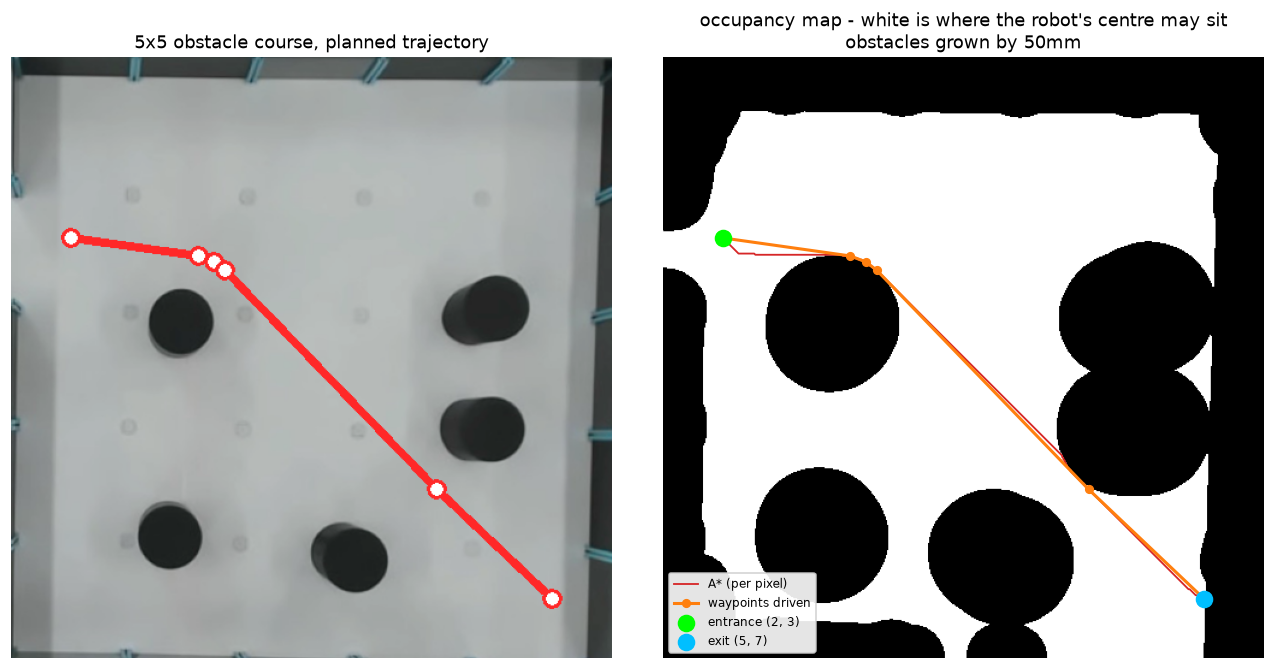

In [12]:
# The figure the brief asks for: the occupancy map and the trajectory solved on
# it, next to the same trajectory drawn over the photo of the course.
zone_rgb = cv2.cvtColor(zone_roi(maze_img), cv2.COLOR_BGR2RGB).copy()

for p, q in zip(waypoints, waypoints[1:]):
    cv2.line(zone_rgb, p, q, (255, 40, 40), 5)
for p in waypoints:
    cv2.circle(zone_rgb, p, 7, (255, 255, 255), -1)
    cv2.circle(zone_rgb, p, 7, (255, 40, 40), 2)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(zone_rgb)
ax[0].set_title(f"{ZONE_SIZE}x{ZONE_SIZE} obstacle course, planned trajectory")

ax[1].imshow(free_space_mask, cmap="gray")
ax[1].plot([p[0] for p in dense_path], [p[1] for p in dense_path],
           color="tab:red", lw=1.2, label="A* (per pixel)")
ax[1].plot([p[0] for p in waypoints], [p[1] for p in waypoints],
           color="tab:orange", lw=2.0, marker="o", ms=5, label="waypoints driven")
ax[1].scatter(*ZONE_START_PX, s=110, c="lime",        zorder=5, label=f"entrance {ZONE_ENTER}")
ax[1].scatter(*ZONE_GOAL_PX,  s=110, c="deepskyblue", zorder=5, label=f"exit {ZONE_EXIT}")
ax[1].set_title(f"occupancy map - white is where the robot's centre may sit\n"
                f"obstacles grown by {CLEARANCE_ACHIEVED:.0f}mm")
ax[1].legend(loc="lower left", fontsize=8, framealpha=0.9)

for a in ax:
    a.set_xlim(0, ZONE_SIZE * CELL_PX)
    a.set_ylim(ZONE_SIZE * CELL_PX, 0)
    a.axis("off")

plt.tight_layout(); plt.show()

## Stage 7 — commands for the robot

Get commands from both 4.1, and the specific turns and movement for 4.2.

In [13]:
TURN = {0: [], 1: ["r"], 2: ["r", "r"], 3: ["l"]}     # clockwise quarter-turns -> commands


def turn_to(heading, facing):
    """Commands that rotate from `heading` to `facing` (180 deg becomes 'rr')."""
    return TURN[(HEADINGS.index(facing) - HEADINGS.index(heading)) % 4]


def path_to_commands(path, heading, final_heading=None):
    """Cell path + starting heading (as 'N'/'E'/'S'/'W') -> (commands, final heading).

    The task 4.1 generator, kept as-is. 4.2 uses generate_discrete_commands(),
    which does the same job in degrees so that it composes with the continuous
    phase.
    """
    commands = []
    for (r0, c0), (r1, c1) in zip(path, path[1:]):
        facing = {(-1, 0): "N", (0, 1): "E", (1, 0): "S", (0, -1): "W"}[(r1 - r0, c1 - c0)]
        commands += turn_to(heading, facing)
        commands.append("f")
        heading = facing

    if final_heading is not None:
        commands += turn_to(heading, final_heading)
        heading = final_heading
    return commands, heading


def replay(maze, start, commands, heading):
    """Independent check: walk the command string, refusing to pass through a wall."""
    r, c = start
    for cmd in commands:
        if cmd == "f":
            assert not maze.wall(r, c, heading), f"command drives into a wall at ({r},{c})"
            dr, dc = DELTA[heading]
            r, c = r + dr, c + dc
        else:
            step = 1 if cmd == "r" else -1
            heading = HEADINGS[(HEADINGS.index(heading) + step) % 4]
    return (r, c), heading


def generate_discrete_commands(path_nodes, start_heading_deg):
    """(row, col) path + starting heading in degrees -> ('f'/'l'/'r' string, final heading).

    Degrees are CCW-positive with 0 = East, per HEADING_DEG - the same convention
    generate_relative_commands() works in, so the heading this returns can be
    handed straight to it. It could not before: this function used to call North
    -90 and South +90, i.e. clockwise-positive, which agrees with the continuous
    half only for East and West. Entering the obstacle course facing North or
    South produced a first turn that was 180 degrees out.

    +ve is CCW is left, so a required turn of +90 is an 'l'.
    """
    cmds = ""
    heading = float(start_heading_deg)

    for (r1, c1), (r2, c2) in zip(path_nodes, path_nodes[1:]):
        if   r2 < r1: required = HEADING_DEG["N"]     # row 0 is the top of the photo
        elif r2 > r1: required = HEADING_DEG["S"]
        elif c2 > c1: required = HEADING_DEG["E"]
        elif c2 < c1: required = HEADING_DEG["W"]
        else:         continue

        turn = round_half_away(((required - heading) + 180) % 360 - 180)

        if   turn ==   90:      cmds += "l"
        elif turn ==  -90:      cmds += "r"
        elif abs(turn) == 180:  cmds += "rr"
        elif turn != 0:
            raise ValueError(f"grid phase asked for a {turn} deg turn, which is not a quarter turn")

        cmds += "f"
        heading = required

    return cmds, heading


def generate_relative_commands(waypoints, initial_heading_deg):
    """Waypoints in zone pixels -> [{turn_deg, drive_mm}], each relative to the last.

    Angles are CCW-positive with 0 = East. The y difference is negated because
    the image y axis points down, which is what puts this in the same convention
    as HEADING_DEG and as the firmware's turnByAngleProfiled (TURN_LEFT = +90).
    """
    commands = []
    heading = float(initial_heading_deg)

    for (x1, y1), (x2, y2) in zip(waypoints, waypoints[1:]):
        dist_mm = math.hypot(x2 - x1, y2 - y1) * MM_PER_PX
        angle_deg = math.degrees(math.atan2(-(y2 - y1), x2 - x1))

        turn_deg = (angle_deg - heading + 180) % 360 - 180   # normalise to [-180, 180]

        commands.append({"turn_deg": round(turn_deg, 1),
                         "drive_mm": round(dist_mm, 1)})
        heading = angle_deg

    return commands

In [14]:
def build_master_mission(start_node, zone_enter, zone_exit, goal_node,
                         initial_heading, waypoints, maze_obj):
    """The whole run as one command list, plus every piece that went into it.

    Returned as a dict rather than just the command strings so the trajectory
    plot and both header exports read the same numbers. They used to disagree:
    the 5x5 export re-derived its turns from a hardcoded entry heading and so
    differed from the master mission about the very first turn of the course.

    Commands, matching chainMission() in task4_2ChainingMovements.hpp:

        'f' / 'l' / 'r'   grid phase, one cell or one quarter turn
        'T' <deg>         turn, CCW-positive       (obstacle course)
        'D' <mm>          drive straight           (obstacle course)
        'S'               snap the heading back onto the grid
    """
    # ------------------------------------------------- Phase 1: start -> course
    path_a = maze_obj.bfs(start_node, zone_enter)
    if path_a is None:
        raise ValueError(f"PATH BLOCKED: no route from start {start_node} "
                         f"to the course entrance {zone_enter}")

    path_a_str, heading_at_entrance = generate_discrete_commands(path_a, initial_heading)
    commands = [f"{{'{ch}', 0.0}}" for ch in path_a_str]

    # ------------------------------- Phase 2: the course, on the heading phase 1
    # actually ended on rather than one assumed in advance.
    zone_commands = generate_relative_commands(waypoints, heading_at_entrance)

    heading = heading_at_entrance
    for cmd in zone_commands:
        heading += cmd["turn_deg"]

        # Every turn is exported, including ones too small for the robot to
        # execute. chainMission() skips executing those but still adds them to
        # its heading, so filtering them out here would leave the two
        # accumulators disagreeing and mis-plan everything after the snap.
        # Drives are different - dropping one costs a few mm of position and
        # nothing else - and simplify_path has already merged the short legs
        # away, so this should not fire at all.
        commands.append(f"{{'T', {cmd['turn_deg']}}}")
        if abs(cmd["drive_mm"]) >= MIN_DRIVE_MM:
            commands.append(f"{{'D', {cmd['drive_mm']}}}")
        else:
            print(f"  note: dropping a {cmd['drive_mm']}mm leg, below the drive deadband")

    # ------------------------------------------------ Phase 3: back onto the grid
    commands.append("{'S', 0.0}")
    # round_half_away, not round(), because the firmware snaps with C's roundf
    # and this has to predict that exactly. See round_half_away.
    snapped_heading = round_half_away(heading / 90.0) * 90.0

    # -------------------------------------------------- Phase 4: course -> goal
    path_b = maze_obj.bfs(zone_exit, goal_node)
    if path_b is None:
        raise ValueError(f"PATH BLOCKED: no route from the course exit {zone_exit} "
                         f"to the goal {goal_node}")

    path_b_str, final_heading = generate_discrete_commands(path_b, snapped_heading)
    commands += [f"{{'{ch}', 0.0}}" for ch in path_b_str]

    return {
        "commands":        commands,
        "path_a":          path_a,
        "path_b":          path_b,
        "path_a_str":      path_a_str,
        "path_b_str":      path_b_str,
        "zone_commands":   zone_commands,
        "entry_heading":   heading_at_entrance,
        "exit_heading":    heading,
        "snapped_heading": snapped_heading,
        "final_heading":   final_heading,
    }


mission = build_master_mission(START, ZONE_ENTER, ZONE_EXIT, GOAL,
                               START_HEADING, waypoints, maze)

print(f"phase 1  {START} -> {ZONE_ENTER}   '{mission['path_a_str']}'"
      f"   ends facing {mission['entry_heading']:+.0f} deg")
print(f"phase 2  the course, {len(mission['zone_commands'])} segments,"
      f"   ends facing {mission['exit_heading']:+.1f} deg")
print(f"phase 3  snap to {mission['snapped_heading']:+.0f} deg"
      f"   ({mission['snapped_heading'] - mission['exit_heading']:+.1f} deg)")
print(f"phase 4  {ZONE_EXIT} -> {GOAL}   '{mission['path_b_str']}'"
      f"   ends facing {mission['final_heading']:+.0f} deg")
print(f"\n{len(mission['commands'])} commands total")

phase 1  (2, 2) -> (2, 3)   'f'   ends facing +0 deg
phase 2  the course, 5 segments,   ends facing -43.5 deg
phase 3  snap to +0 deg   (+43.5 deg)
phase 4  (5, 7) -> (6, 7)   'rf'   ends facing -90 deg

14 commands total


Full Route Plot

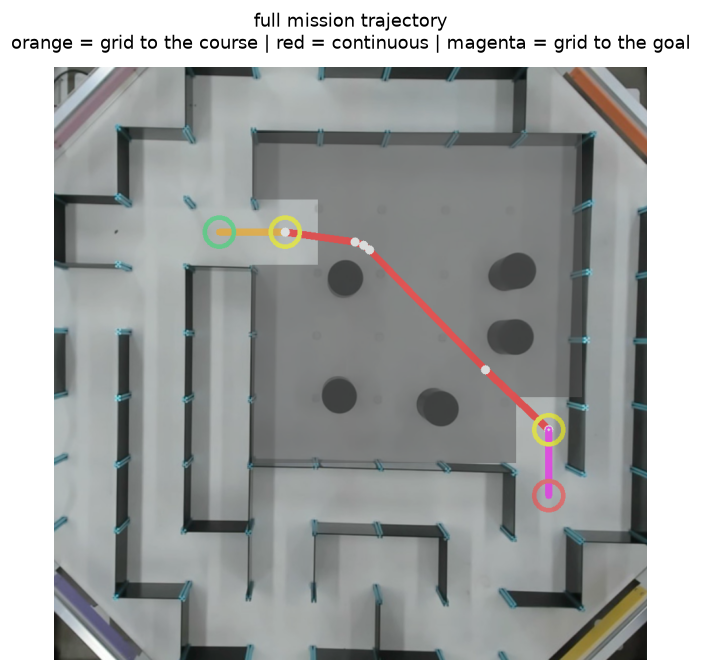

In [15]:
def plot_master_mission(maze_img, mission, waypoints):
    """The whole run over the rectified board: both grid phases and the course."""
    rgb = cv2.cvtColor(maze_img, cv2.COLOR_BGR2RGB)
    overlay = rgb.copy()

    pts_a = [cell_centre(r, c) for r, c in mission["path_a"]]
    pts_b = [cell_centre(r, c) for r, c in mission["path_b"]]

    # Waypoints are in the zone ROI's frame, so shift them back onto the board.
    offset_x, offset_y = ZONE_START_C * CELL_PX, ZONE_START_R * CELL_PX
    pts_w = [(x + offset_x, y + offset_y) for x, y in waypoints]

    # Shade the cells the grid search was not allowed into, so it is visible that
    # the orange and magenta legs go around the course rather than through it.
    for r, c in sorted(maze.blocked):
        cv2.rectangle(overlay, (c * CELL_PX, r * CELL_PX),
                      ((c + 1) * CELL_PX, (r + 1) * CELL_PX), (90, 90, 90), -1)

    for p, q in zip(pts_a, pts_a[1:]):          # phase 1, orange
        cv2.line(overlay, p, q, (255, 165, 0), 10)

    for p, q in zip(pts_w, pts_w[1:]):          # phase 2, red
        cv2.line(overlay, p, q, (255, 0, 0), 10)
    for p in pts_w:
        cv2.circle(overlay, p, 7, (255, 255, 255), -1)

    for p, q in zip(pts_b, pts_b[1:]):          # phase 4, magenta
        cv2.line(overlay, p, q, (255, 0, 255), 10)

    # The handovers between phases.
    cv2.line(overlay, pts_a[-1], pts_w[0], (255, 255, 255), 4)
    cv2.line(overlay, pts_w[-1], pts_b[0], (255, 255, 255), 4)

    cv2.circle(overlay, pts_a[0],  22, (46, 220, 110), 6)   # start
    cv2.circle(overlay, pts_a[-1], 22, (255, 255, 0), 6)    # course entrance
    cv2.circle(overlay, pts_b[0],  22, (255, 255, 0), 6)    # course exit
    cv2.circle(overlay, pts_b[-1], 22, (255, 64, 64), 6)    # goal

    out = cv2.addWeighted(rgb, 0.45, overlay, 0.55, 0)

    plt.figure(figsize=(7, 7))
    plt.imshow(out)
    plt.title("full mission trajectory\n"
              "orange = grid to the course | red = continuous | magenta = grid to the goal",
              fontsize=12, pad=12)
    plt.axis("off")
    plt.show()


plot_master_mission(maze_img, mission, waypoints)

## Stage 7b - hand it to the firmware

Two headers, both written next to this notebook:

* `5x5_route.h` - the obstacle course on its own, for bench-testing the
  continuous phase without driving the whole maze.
* `4_2_full_route.h` - the whole run. Drop it in `src/task4_code/` and call
  `chainMission(mouse)` from `task4_code/task4_2ChainingMovements.hpp`.

Both are derived from the same `mission` dict, so they cannot disagree about the
heading the course is entered on.

In [16]:
# The obstacle course on its own, for bench-testing the continuous phase without
# driving the whole maze. Derived from the same mission the master export uses,
# so the two cannot drift apart - this used to be regenerated from a hardcoded
# entry heading and disagreed with the master mission about the first turn.
zone_commands = mission["zone_commands"]

print("--- CONTINUOUS COMMANDS EXPORT ---")
print(f"entering the course facing {mission['entry_heading']:+.0f} deg "
      f"(CCW-positive, 0 = East)\n")

heading = mission["entry_heading"]
for i, cmd in enumerate(zone_commands, 1):
    heading += cmd["turn_deg"]
    note = "  (turn below the robot's deadband, it will be skipped)" \
        if abs(cmd["turn_deg"]) < MIN_TURN_DEG else ""
    print(f"  {i}: turn {cmd['turn_deg']:>7.1f} deg | drive {cmd['drive_mm']:>6.1f} mm"
          f" | now facing {heading:>7.1f}{note}")

c_array = ", ".join(f"{{{c['turn_deg']}, {c['drive_mm']}}}" for c in zone_commands)

c_header = f"""#pragma once
// Generated by task4_code/image_processing_4_2.ipynb for Task 4.2.
// The obstacle course only - see 4_2_full_route.h for the whole run.
//
// Turns are degrees, CCW-positive (a +ve turn is a left turn, matching
// TURN_LEFT in MicromouseData.hpp). Drives are mm.
//
// Entered facing {mission['entry_heading']:+.0f} deg, from cell {ZONE_ENTER} to cell {ZONE_EXIT}.
// Planned with the obstacles grown by {CLEARANCE_ACHIEVED:.0f}mm.

struct WaypointCmd {{
    float turn_deg;
    float drive_mm;
}};

constexpr int NUM_WAYPOINTS = {len(zone_commands)};
constexpr WaypointCmd OBSTACLE_ROUTE[NUM_WAYPOINTS] = {{
    {c_array}
}};
"""

with open("5x5_route.h", "w") as f:
    f.write(c_header)

print("\nexported to '5x5_route.h'")

--- CONTINUOUS COMMANDS EXPORT ---
entering the course facing +0 deg (CCW-positive, 0 = East)

  1: turn    -8.1 deg | drive  192.7 mm | now facing    -8.1
  2: turn   -13.0 deg | drive   25.1 mm | now facing   -21.1
  3: turn   -16.8 deg | drive   20.5 mm | now facing   -37.9
  4: turn    -8.1 deg | drive  455.7 mm | now facing   -46.0
  5: turn     2.5 deg | drive  238.1 mm | now facing   -43.5  (turn below the robot's deadband, it will be skipped)

exported to '5x5_route.h'


In [17]:
c_array = ",\n    ".join(mission["commands"])

c_header = f"""#pragma once
// Master mission profile for Task 4.2.
// Generated by task4_code/image_processing_4_2.ipynb from {PHOTO} - do not hand-edit.
//
// Run it with chainMission(mouse) from task4_code/task4_2ChainingMovements.hpp.
//
//   'f' / 'l' / 'r'   one cell forward / quarter turn, in the maze
//   'T' <deg>         turn by an arbitrary angle, CCW-positive, in the course
//   'D' <mm>          drive straight, in the course
//   'S'               snap the heading back onto the maze grid
//
// Start {START} facing {START_HEADING:+.0f} deg (0 = East, CCW-positive). The robot must be
// placed on this heading, and MISSION_START_HEADING must match it.
// Course {ZONE_ENTER} -> {ZONE_EXIT}, planned with the obstacles grown by {CLEARANCE_ACHIEVED:.0f}mm.
// Goal {GOAL}, reached facing {mission['final_heading']:+.0f} deg.

struct Command {{
    char action;
    float value;
}};

constexpr int NUM_COMMANDS = {len(mission['commands'])};
constexpr Command MISSION[NUM_COMMANDS] = {{
    {c_array}
}};
"""

with open("4_2_full_route.h", "w") as f:
    f.write(c_header)

print(f"exported {len(mission['commands'])} commands to '4_2_full_route.h'")
print("\n".join("  " + c for c in mission["commands"]))

exported 14 commands to '4_2_full_route.h'
  {'f', 0.0}
  {'T', -8.1}
  {'D', 192.7}
  {'T', -13.0}
  {'D', 25.1}
  {'T', -16.8}
  {'D', 20.5}
  {'T', -8.1}
  {'D', 455.7}
  {'T', 2.5}
  {'D', 238.1}
  {'S', 0.0}
  {'r', 0.0}
  {'f', 0.0}
